# Encoder Training

Defines and trains the VAE encoder/decoder stack over the cleaned features.

> Generated from `Lab2_multi_task_modal.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import ast
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import tensorflow as tf
import tensorflow.keras
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import plotly.io as plt_io
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import itertools
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
import random
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, auc, classification_report
%matplotlib inline

## Creating Variational Autoencoder (VAE)

Intuition behind VAE: https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73

A variational autoencoder (VAE) is a generative model consisting of an encoder and a decoder. The encoder learns to map data from a high-dimensional input space to a low-dimensional latent space, and the corresponding decoder maps the latent space back to the input space. Unlike traditional autoencoders, VAEs uses variational inference to force a regularized distribution on the latent space. This is done so by modifying the loss function to include a KL divergence term. The KL divergence term is a measure of how different the latent space distribution is from a standard normal distribution. The KL divergence term is minimized by the VAE so the latent space distribution is as close to a standard normal distribution as possible. This is done so the latent space is smooth and distances between points in the latent space are meaningful. The VAE is trained by minimizing the sum of the reconstruction loss and the KL divergence term. In the simplest methods, the reconstruction loss is defined by either mean squared error or binary cross entropy.

In [8]:
from tensorflow.keras import losses

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # reconstruction_loss = tf.reduce_mean(
            #     tf.reduce_sum(
            #         keras.losses.mean_squared_error(data, reconstruction), axis=None
            #     )
            # )
            reconstruction_loss = losses.binary_crossentropy(data, reconstruction)
            #experiment with assing a lambda value to the kl_loss
            kl_loss = (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = -5e-4 * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(z_log_var) * epsilon

Before creating my embedding, I will perform a train test split on my data. This way I can evaluate my VAE and oveall model with songs that were not included in embedding matrix.

In [9]:
#split the data into train and test with genre_group as the the label
X_train_embedding, X_test_embedding, y_train_embedding, y_test_embedding = train_test_split(songs_df.drop(columns=['genre_group']), songs_df['genre_group'], test_size=0.2, random_state=42, stratify=songs_df['genre_group'])

#preprocessing first
ohe = OneHotEncoder()
scaler = StandardScaler()

#separate into numberical and categorical features
X_train_embedding_num = X_train_embedding.drop(columns=['key', 'mode'])

X_test_embedding_num = X_test_embedding.drop(columns=['key', 'mode'])

#one-hot encode the key label
train_key = ohe.fit_transform(X_train_embedding['key'].values.reshape(-1, 1)).toarray()
test_key = ohe.transform(X_test_embedding['key'].values.reshape(-1, 1)).toarray()

train_mode = X_train_embedding['mode'].values.reshape(-1, 1)
test_mode = X_test_embedding['mode'].values.reshape(-1, 1)

#creating categorical dataframe which combines the one-hot encoded key and the mode
X_train_embedding_cat = np.concatenate((train_key,train_mode), axis=1)
X_test_embedding_cat = np.concatenate((test_key,test_mode), axis=1)

#standardizing the numerical features
X_train_embedding_num = scaler.fit_transform(X_train_embedding_num)
X_test_embedding_num = scaler.transform(X_test_embedding_num)

#concatenate the one-hot encoded key and the numerical features
X_train_embedding = np.concatenate((X_train_embedding_num, X_train_embedding_cat), axis=1)
X_test_embedding = np.concatenate((X_test_embedding_num, X_test_embedding_cat), axis=1)

#print train and test shapes
print(X_train_embedding.shape)
print(X_test_embedding.shape)


(25760, 24)
(6440, 24)


In [10]:
#print the ttrain embedding using pandas
pd.DataFrame(X_train_embedding).head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-0.240350,-0.637297,0.386088,-0.626879,0.967848,-0.344560,-0.491509,-1.034563,0.186780,-0.856993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.258699,0.716684,1.011443,0.608338,-0.461782,-0.344536,1.795165,0.200241,-1.016544,-1.157097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.093555,0.546878,0.869877,-0.332827,-0.580526,-0.344549,-0.621665,-0.236056,0.966341,-0.016701,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.882062,0.265357,0.136358,1.631130,-0.323865,-0.344560,3.419121,1.076952,-0.264462,-1.097076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.540057,-0.449617,0.533306,0.372310,0.234532,-0.344560,-0.013875,0.846455,-0.010696,-0.676931,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Encoder

In [11]:
latent_dim = 12

encoder_inputs = keras.Input(shape=(X_train_embedding.shape[1],))
x =layers.Dense(19, activation="relu")(encoder_inputs)
x = layers.Dense(15, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 24)]         0           []                               
                                                                                                  
 dense (Dense)                  (None, 19)           475         ['input_1[0][0]']                
                                                                                                  
 dense_1 (Dense)                (None, 15)           300         ['dense[0][0]']                  
                                                                                                  
 z_mean (Dense)                 (None, 12)           192         ['dense_1[0][0]']                
                                                                                            

2023-04-22 16:18:10.340561: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Decoder

In [12]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(15, activation="relu")(latent_inputs)
x = layers.Dense(19, activation="relu")(x)
decoder_outputs = layers.Dense(X_train_embedding.shape[1], activation="tanh")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_2 (Dense)             (None, 15)                195       
                                                                 
 dense_3 (Dense)             (None, 19)                304       
                                                                 
 dense_4 (Dense)             (None, 24)                480       
                                                                 
Total params: 979
Trainable params: 979
Non-trainable params: 0
_________________________________________________________________


### VAE Training

In [13]:
# instantiate and run the VAE model
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train_embedding, epochs=100, batch_size=32, shuffle=True)


Epoch 1/100
805/805 [==============================] - 1s 1ms/step - loss: 0.4123 - reconstruction_loss: 0.1931 - kl_loss: 0.0023
Epoch 2/100
805/805 [==============================] - 1s 1ms/step - loss: -0.3450 - reconstruction_loss: -0.4373 - kl_loss: 0.0062
Epoch 3/100
805/805 [==============================] - 1s 970us/step - loss: -0.5378 - reconstruction_loss: -0.6356 - kl_loss: 0.0089
Epoch 4/100
805/805 [==============================] - 1s 964us/step - loss: -0.8006 - reconstruction_loss: -0.8238 - kl_loss: 0.0141
Epoch 5/100
805/805 [==============================] - 1s 967us/step - loss: -0.8690 - reconstruction_loss: -0.9225 - kl_loss: 0.0151
Epoch 6/100
805/805 [==============================] - 1s 971us/step - loss: -1.0138 - reconstruction_loss: -1.0307 - kl_loss: 0.0163
Epoch 7/100
805/805 [==============================] - 1s 1ms/step - loss: -1.0894 - reconstruction_loss: -1.1624 - kl_loss: 0.0198
Epoch 8/100
805/805 [==============================] - 1s 961us/step -

Text(0, 0.5, 'Loss')

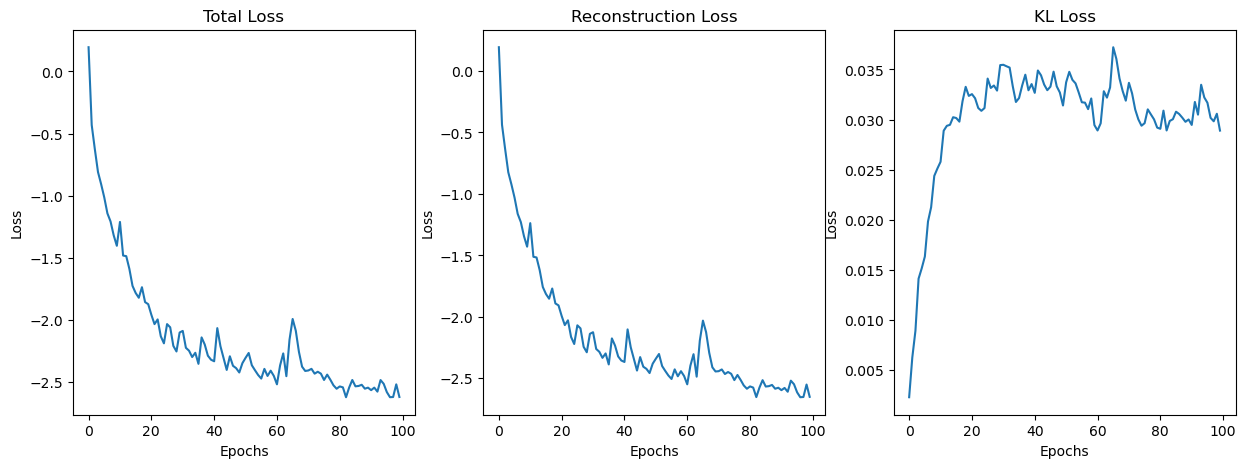

In [14]:
#plot the loss, reconstruction loss, and KL loss 3 in separate plots side by side
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(vae.history.history['loss'])
plt.title('Total Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
plt.plot(vae.history.history['reconstruction_loss'])
plt.title('Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 3, 3)
plt.plot(vae.history.history['kl_loss'])
plt.title('KL Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [15]:
latent_space, _, _ = encoder.predict(X_train_embedding)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(latent_space)

# Convert the data to a pandas DataFrame
df = pd.DataFrame({'pca0': X_train_pca[:, 0], 'pca1': X_train_pca[:, 1], 'genre_group': y_train_embedding})

# Create a scatter plot using Plotly
fig = px.scatter(df, x='pca0', y='pca1', color='genre_group')

# Add labels and adjust the layout
fig.update_layout(
    title='PCA Latent Space Visualization',
    xaxis_title='pca0',
    yaxis_title='pca1',
    legend_title='Genre Group'
)

# Display the plot
fig.show()

805/805 [==============================] - 1s 1ms/step


Text(0, 0.5, 'cumulative explained variance')

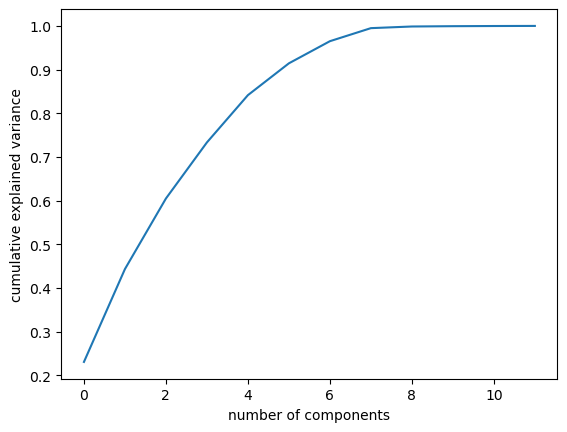

In [16]:
# create a scree plot to see how many components to keep
pca = PCA()
pca.fit(latent_space)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')



Scree plot to visualize the variance explained by each latent dimension, this is a good way to determine the number of latent dimensions to use.

